# 1 Boyutlu Kompleks Değerli Evrişimli Yapay Sinir Ağları (1B KD EYSA) ile DNA-KODON- AMİNO ASİT Dizi Sınıflandırma
#### Açıklama: 
- Daha önce; İnsan vucuduna ait ve yaklaşık 500 ve üzeri protein çeşitliliği içeren Kinaz ve GPCR protein aileleri için UniProt uzantılı erişm (Acces) noları ile oluşturulan havuzdan herbir protein ailesi için basit rastgele örnekleme yöntemiyle (Simple Random Sampling) Train için 200 er örnek ve test için 100 er örnek seçilmiş; UniProt ve NCBI gen bankasından uzantılı erişm (Acces) numaralarıyla CDS-DNA, KODON ve AMİNOASİT dizi formları fasta olarak indirilmiş; indirilen herbir dizi formuna ait örnekler, önerilen kompleks değerli yöntemler kullanılarak kompleks sayılara kodlanmış ve her bir dizi formu için .npz dosyasına train (Train toplam: 400) ve test (Test toplam: 200) olarak kaydedilmiştir.(DNA 900 nt = 300 kodon; amino asit 300 uzunluk)
- Bu bölümde ise; kompleks değerlere dönüştürülmüş Kinaz ve GPCR proteinlerine ait DNA, KODON ve AMİNO ASİT dizileri 1 Boyutlu Kompleks Değerli Evrişimli Yapay Sinir Ağları (1B KD EYSA) kullanılarak sınıflandırılmasktadır. Sonuçlar grafiklerle görselleştirilmektedir.

### Çalışma Adımları:
#### 1. Adım: 1B KD EYSA ile DNA dizisi sınıflandırma
- Kompleks değerlere dönüştürülmüş DNA dizileriyle Kinaz–GPCR sınıflandırması yapılır.
- 400 eğitim örneği üzerinde 10 katlı çapraz doğrulama (10-fold CV) ile model değerlendirilir; ardından aynı havuzla model yeniden eğitilir ve .npz içindeki 200 bağımsız test örneği (X_test) üzerinde nihai test yapılır.

#### 2. Adım: 1B KD EYSA ile KODON dizisi sınıflandırma
- Kompleks değerlere dönüştürülmüş KODON dizileriyle Kinaz–GPCR sınıflandırması yapılır.
- 400 eğitim örneği üzerinde 10 katlı çapraz doğrulama ile model değerlendirilir; ardından aynı havuzla model yeniden eğitilir ve 200 bağımsız test örneği üzerinde nihai test yapılır.

#### 3. Adım: 1B KD EYSA ile AMİNO ASİT dizisi sınıflandırma
- Kompleks değerlere dönüştürülmüş AMİNO ASİT dizileriyle Kinaz–GPCR sınıflandırması yapılır.
- 400 eğitim örneği üzerinde 10 katlı çapraz doğrulama ile model değerlendirilir; ardından aynı havuzla model yeniden eğitilir ve 200 bağımsız test örneği üzerinde nihai test yapılır.

## 1.Adım: 1B KD EYSA  ile kompleks değerli DNA dizisi sınıflandırma:
- Kompleks değerlere dönüştürülmüş DNA dizileriyle Kinaz–GPCR sınıflandırması yapılır.
- 400 eğitim örneği üzerinde 10 katlı çapraz doğrulama (10-fold CV) ile model değerlendirilir; ardından aynı havuzla model yeniden eğitilir ve .npz içindeki 200 bağımsız test örneği (X_test) üzerinde nihai test yapılır.
- Sonuçlar grafiklerle görselleştirilir.

In [7]:
# =============================================================================
#   1D EVRİŞİMLİ KOMPLEKS DEĞERLİ YAPAY SİNİR AĞI (1B-KD EYSA) — DNA
#   L = 900   |   Veri kaynağı: cds_DNA_Compleks_L900.npz
#   (WİRTİNGER HİBRİT TOPLAM LOSS/KAYIP)
#
# =============================================================================

import os
import random
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#   SABİTLER
# =============================================================================
NPZ_YOLU = r"C:\Users\matya\cds_DNA_Compleks_L900.npz"

L                = 900   # DNA: 900 nükleotit
SINIF_SAYISI     = 2
SINIF_ADLARI     = {0: "GPCR", 1: "Kinase"}

GENLIK_NORMALIZASYONU = True

N_SPLITS         = 10
EPOCHS           = 200
BATCH_SIZE       = 12
OGRENME_ORANI    = 2e-4
WEIGHT_DECAY     = 1e-4

# hiperparametreler
LAMBDA_CENTER_HEDEF      = 0.05
LAMBDA_CENTER_BASLANGIC  = 0.0
LAMBDA_WARMUP_EPOCH      = 5
LABEL_SMOOTHING          = 0.02
TEMPERATURE              = 0.5

DROPOUT_ORANLARI         = (0.15, 0.20, 0.25)

CV_CIKTI_XLSX            = "cv_10_fold_1dconv_dna.xlsx"


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Ana run seed       : {RUN_SEED}")
print(f"[INFO] Veri kaynağı       : {NPZ_YOLU}")
print(f"[INFO] L (girdi uzunluğu) : {L}")
print(f"[INFO] Genlik norm. (X/L) : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef     : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Temperature τ      : {TEMPERATURE}")
print(f"[INFO] EarlyStop monitor  : val_dogruluk (max)")
print(f"[INFO] ReduceLR monitor   : val_kayip_ce")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# =============================================================================
#  KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#   KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma_r = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_r")
        self.beta_r  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_r")
        self.gamma_i = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_i")
        self.beta_i  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_i")

    def call(self, z):
        zr = tf.math.real(z)
        zi = tf.math.imag(z)
        axes = list(range(len(z.shape) - 1))

        ort_r  = tf.reduce_mean(zr, axis=axes, keepdims=True)
        var_r  = tf.math.reduce_variance(zr, axis=axes, keepdims=True)
        zr_hat = (zr - ort_r) / tf.sqrt(var_r + self.eps)
        zr_hat = zr_hat * self.gamma_r + self.beta_r

        ort_i  = tf.reduce_mean(zi, axis=axes, keepdims=True)
        var_i  = tf.math.reduce_variance(zi, axis=axes, keepdims=True)
        zi_hat = (zi - ort_i) / tf.sqrt(var_i + self.eps)
        zi_hat = zi_hat * self.gamma_i + self.beta_i

        return tf.complex(zr_hat, zi_hat)


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        mask = tf.nn.dropout(
            tf.ones_like(tf.math.real(z), dtype=tf.float32), rate=self.oran)
        return z * tf.cast(mask, z.dtype)


# =============================================================================
#    KOMPLEKS YOĞUN & CONV
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d         = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikConv1D(layers.Layer):
    def __init__(self, filtre_sayisi, kernel_boyutu, stride=1, padding="same",
                 aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.filtre_sayisi = int(filtre_sayisi)
        self.kernel_boyutu = int(kernel_boyutu)
        self.stride        = int(stride)
        self.padding       = padding.upper()
        self.aktivasyon    = aktivasyon
        self.l2            = float(l2)
        self.seed          = int(seed)

    def build(self, input_shape):
        ic        = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None
        ks        = (self.kernel_boyutu, ic, self.filtre_sayisi)

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.kr = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="kr")
        self.ki = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="ki")
        self.br = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = (tf.nn.conv1d(xr, self.kr, stride=self.stride, padding=self.padding)
              - tf.nn.conv1d(xi, self.ki, stride=self.stride, padding=self.padding)
              + self.br)
        yi = (tf.nn.conv1d(xr, self.ki, stride=self.stride, padding=self.padding)
              + tf.nn.conv1d(xi, self.kr, stride=self.stride, padding=self.padding)
              + self.bi)
        y = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikMaxPool1D(layers.Layer):
    def __init__(self, pool_size=2, strides=2, padding="same", **kwargs):
        super().__init__(**kwargs)
        self.pool_size = int(pool_size)
        self.strides   = int(strides)
        self.padding   = padding.upper()

    def call(self, z):
        return tf.complex(
            tf.nn.max_pool1d(tf.math.real(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding),
            tf.nn.max_pool1d(tf.math.imag(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding))


class KarmasikGlobalAveragePooling1D(layers.Layer):
    def call(self, z):
        return tf.complex(tf.reduce_mean(tf.math.real(z), axis=1),
                          tf.reduce_mean(tf.math.imag(z), axis=1))


# =============================================================================
#   WIRTINGER CE & CENTER KAYBI
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):

    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):

    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 temperature=0.5, stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.temperature         = float(temperature)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        logit = -enerji / self.temperature
        return logit, enerji


# =============================================================================
#     EĞİTİCİ MODEL
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#    CALLBACKS
# =============================================================================
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=5, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


def callback_listesi_olustur(reduce_lr_patience=10, early_stop_patience=25,
                             reduce_verbose=0, early_verbose=0,
                             scheduler_verbose=0):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_dogruluk", mode="max",
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_kayip_ce", factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=scheduler_verbose),
    ]


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               dropout_oranlari=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI,
               temperature=TEMPERATURE):

    d1, d2, d3 = dropout_oranlari

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")
    x     = layers.Reshape((L, 1), name="reshape_1d")(giris)

    # Blok 1
    x = KarmasikConv1D(16, 7, stride=1, padding="same", aktivasyon=None,
                       l2=wd, seed=seed,     name="kconv1")(x)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_1")(x)
    x = KarmasikDropout(oran=d1, name="drop_1")(x)

    # Blok 2
    x = KarmasikConv1D(32, 5, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 1, name="kconv2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_2")(x)
    x = KarmasikDropout(oran=d2, name="drop_2")(x)

    # Blok 3
    x = KarmasikConv1D(48, 3, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 2, name="kconv3")(x)
    x = KarmasikKatmanNorm(name="norm_3")(x)
    x = KarmasikDropout(oran=d3, name="drop_3")(x)

    x = KarmasikGlobalAveragePooling1D(name="kgap")(x)

    z = KarmasikYogun(16, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 3, name="yogun_son")(x)
    z = KarmasikKatmanNorm(name="norm_son")(z)

    kodlayici = Model(giris, z, name="Karmasik1DConvKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      temperature=temperature,
                                      seed=seed + 4, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=LAMBDA_CENTER_BASLANGIC,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme (bilgi notu ortak şeması)
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):

    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    assert X_tr.shape[1] == L, f"Eğitim dizi uzunluğu {X_tr.shape[1]} != L={L}"
    assert X_te.shape[1] == L, f"Test dizi uzunluğu {X_te.shape[1]} != L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,        y_test,        y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n=== VERİ BİLGİSİ ===")
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")
print("====================\n")


# =============================================================================
#     10-FOLD CV
# =============================================================================
skf            = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                                 random_state=SPLIT_SEED)
fold_sonuclari = []
histories      = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model     = modeli_kur(L=L, seed=fold_seed)
    callbacks = callback_listesi_olustur()

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)
    histories.append(history.history)

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec,
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss": best_val_loss,
        "best_val_acc":  best_val_acc,
        "best_val_ce":   best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":  len(h["kayip"]),
    })

    print(f"Fold Acc      : {fold_acc:.4f}  |  Macro F1  : {macro_f1:.4f}")
    print(f"GPCR F1       : {f1_cls[0]:.4f}  |  Kinase F1 : {f1_cls[1]:.4f}")
    print(f"Best Val Acc  : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı  : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit, 1D-Conv, DNA)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce", "best_val_center",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_precision", "macro_recall", "macro_f1",
          "gpcr_precision", "gpcr_recall", "gpcr_f1",
          "kinase_precision", "kinase_recall", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:25s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    reduce_lr_patience=10, early_stop_patience=25,
    reduce_verbose=1, early_verbose=1, scheduler_verbose=1)

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE, shuffle=True,
    callbacks=final_callbacks, verbose=1)


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval   = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
macro_prec_t, macro_rec_t, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST SONUCU  (1D-Conv KDYSA, DNA)")
print("=" * 55)
print("Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy        : {test_acc:.4f}")
print(f"Test Loss (toplam)   : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE    : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt   : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1        : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R        : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R        : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")

[INFO] Ana run seed       : 5764926
[INFO] Veri kaynağı       : C:\Users\matya\cds_DNA_Compleks_L900.npz
[INFO] L (girdi uzunluğu) : 900
[INFO] Genlik norm. (X/L) : True
[INFO] λ_center hedef     : 0.05 (warmup: 5 epoch)
[INFO] Temperature τ      : 0.5
[INFO] EarlyStop monitor  : val_dogruluk (max)
[INFO] ReduceLR monitor   : val_kayip_ce

=== VERİ BİLGİSİ ===
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 900)  |  X_test (200, 900)
|X| aralığı : [0.001111, 1]  (genlik_bol=True)


  FOLD 1/10
Fold Acc      : 0.9750  |  Macro F1  : 0.9750
GPCR F1       : 0.9744  |  Kinase F1 : 0.9756
Best Val Acc  : 0.9750  |  Best Val CE : 0.0758
Epoch sayısı  : 27

  FOLD 2/10
Fold Acc      : 0.9000  |  Macro F1  : 0.8997
GPCR F1       : 0.8947  |  Kinase F1 : 0.9048
Best Val Acc  : 0.9000  |  Best Val CE : 0.0677
Epoch sayısı  : 26

  FOLD 3/10
Fold Acc      : 0.8750  |  Macro F1  : 0.8743
GPCR F1       : 0.8649  |  Kinase F1 : 0.8837
Be

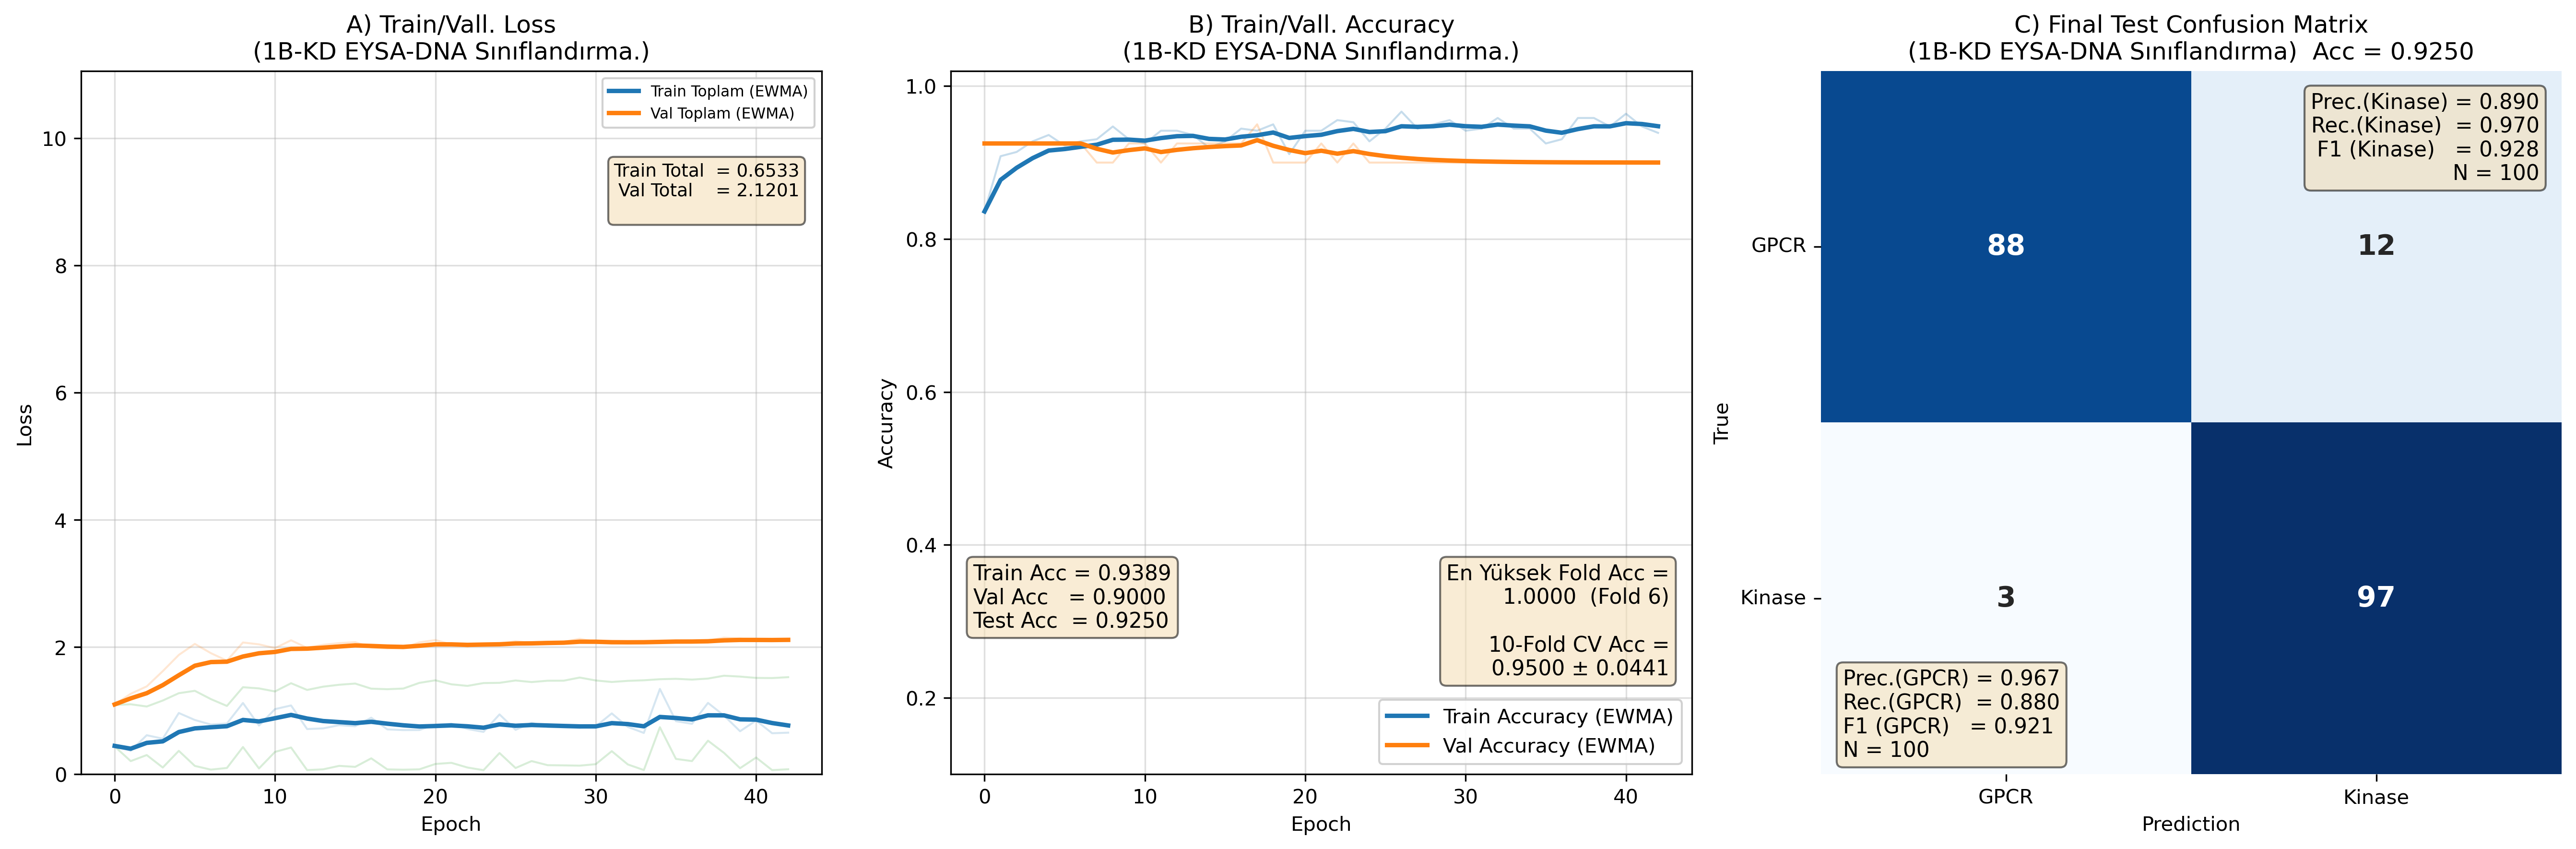

In [8]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B EVRİŞİMLİ KDYSA   [DNA / Kodon / AA ortak]
# 
#
#   Panel A : Toplam + CE + Center Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#

# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algıla
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "KDYSA"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse  


# -------------------------------------------------------------------------
# 1.  History anahtarları — 1D Conv KDYSA ile birebir eşleşir
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham   = np.asarray(h[LOSS_KEY],       dtype=float)
val_loss_ham     = np.asarray(h[VAL_LOSS_KEY],   dtype=float)
train_acc_ham    = np.asarray(h[ACC_KEY],         dtype=float)
val_acc_ham      = np.asarray(h[VAL_ACC_KEY],     dtype=float)

# CE ve Center bileşen dizileri
train_ce_ham     = np.asarray(h.get(CE_KEY,     [np.nan]), dtype=float)
val_ce_ham       = np.asarray(h.get(VAL_CE_KEY, [np.nan]), dtype=float)
train_ctr_ham    = np.asarray(h.get(CENTER_KEY,     [np.nan]), dtype=float)
val_ctr_ham      = np.asarray(h.get(VAL_CENTER_KEY, [np.nan]), dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)
train_ce_sm   = ewma_yumusat(train_ce_ham,   alpha=0.25)
val_ce_sm     = ewma_yumusat(val_ce_ham,     alpha=0.25)
train_ctr_sm  = ewma_yumusat(train_ctr_ham,  alpha=0.25)
val_ctr_sm    = ewma_yumusat(val_ctr_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son   = float(train_loss_ham[-1])
val_loss_son     = float(val_loss_ham[-1])
train_acc_son    = float(train_acc_ham[-1])
val_acc_son      = float(val_acc_ham[-1])
train_ce_son     = float(train_ce_ham[-1])   if CE_KEY     in h else np.nan
val_ce_son       = float(val_ce_ham[-1])     if VAL_CE_KEY in h else np.nan
train_center_son = float(train_ctr_ham[-1])  if CENTER_KEY     in h else np.nan
val_center_son   = float(val_ctr_ham[-1])    if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet  — 1D Conv KDYSA sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_best_val_ce_mean   = cv_df["best_val_ce"].mean()      # 
cv_best_val_ce_std    = cv_df["best_val_ce"].std(ddof=1)
cv_best_val_ctr_mean  = cv_df["best_val_center"].mean()  
cv_best_val_ctr_std   = cv_df["best_val_center"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam + CE + Center son değerler + en düşük fold loss ──────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN  = "#1f77b4"   # mavi  — train
C_VAL    = "#ff7f0e"   # turuncu — val
C_CE     = "#2ca02c"   # yeşil — CE bileşeni
C_CENTER = "#9467bd"   # mor   — Center bileşeni


# ==========================================================================
#  A) Toplam + CE + Center Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham,  color=C_TRAIN,  linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,    color=C_VAL,    linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ce_ham,    color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ce_ham,      color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ctr_ham,   color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ctr_ham,     color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm,  color=C_TRAIN,  linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,    linewidth=2.2, label="Val Toplam (EWMA)")
#ax[0].plot(train_ce_sm,    color=C_CE,     linewidth=1.8, linestyle="--", label="Train CE^ℂ (EWMA)")
#ax[0].plot(val_ce_sm,      color=C_CE,     linewidth=1.8, linestyle=":",  label="Val CE^ℂ (EWMA)")
#ax[0].plot(train_ctr_sm,   color=C_CENTER, linewidth=1.8, linestyle="--", label="Train Cnt^ℂ (EWMA)")
#ax[0].plot(val_ctr_sm,     color=C_CENTER, linewidth=1.8, linestyle=":",  label="Val Cnt^ℂ (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Train/Vall. Loss\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.15))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Train/Vall. Accuracy\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B-KD EYSA-{TEMSIL} Sınıflandırma)  Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_1dconv_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 2.Adım: 1B KD EYSA  ile kompleks değerli KODON dizisi sınıflandırma:
- Daha önce önerilen matematiksel yöntemlerle kompleks değerlere kodlanmış Kodon dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri 1B KD EYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [2]:
# =============================================================================
#   1B EVRİŞİMLİ KOMPLEKS DEĞERLİ YAPAY SİNİR AĞI (1B-KD EYSA) — Kodon
#   L = 300 (300 kodon)   |   Veri kaynağı: cds_KODON_Compleks_L900.npz
#   (WİRTİNGER HİBRİT TOPLAM LOSS/KAYIP)
#
#  
# =============================================================================

import os
import random
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#   SABİTLER
# =============================================================================
NPZ_YOLU = r"C:\Users\matya\cds_KODON_Compleks_L900.npz"

L                = 300   # Kodon: 300 kodon (dizi genişliği; "L900" kaynak CD DNA VERİ SETİ)
SINIF_SAYISI     = 2
SINIF_ADLARI     = {0: "GPCR", 1: "Kinase"}

# Genlik
GENLIK_NORMALIZASYONU = True

N_SPLITS         = 10
EPOCHS           = 200
BATCH_SIZE       = 12
OGRENME_ORANI    = 2e-4
WEIGHT_DECAY     = 1e-4

# hiperparametreler
LAMBDA_CENTER_HEDEF      = 0.05
LAMBDA_CENTER_BASLANGIC  = 0.0
LAMBDA_WARMUP_EPOCH      = 5
LABEL_SMOOTHING          = 0.02
TEMPERATURE              = 0.5

DROPOUT_ORANLARI         = (0.15, 0.20, 0.25)

CV_CIKTI_XLSX            = "cv_10_fold_1dconv_kodon.xlsx"


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Ana run seed       : {RUN_SEED}")
print(f"[INFO] Veri kaynağı       : {NPZ_YOLU}")
print(f"[INFO] L (girdi uzunluğu) : {L}")
print(f"[INFO] Genlik norm. (X/L) : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef     : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Temperature τ      : {TEMPERATURE}")
print(f"[INFO] EarlyStop monitor  : val_dogruluk (max)")
print(f"[INFO] ReduceLR monitor   : val_kayip_ce")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# =============================================================================
#  KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#   KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma_r = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_r")
        self.beta_r  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_r")
        self.gamma_i = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_i")
        self.beta_i  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_i")

    def call(self, z):
        zr = tf.math.real(z)
        zi = tf.math.imag(z)
        axes = list(range(len(z.shape) - 1))

        ort_r  = tf.reduce_mean(zr, axis=axes, keepdims=True)
        var_r  = tf.math.reduce_variance(zr, axis=axes, keepdims=True)
        zr_hat = (zr - ort_r) / tf.sqrt(var_r + self.eps)
        zr_hat = zr_hat * self.gamma_r + self.beta_r

        ort_i  = tf.reduce_mean(zi, axis=axes, keepdims=True)
        var_i  = tf.math.reduce_variance(zi, axis=axes, keepdims=True)
        zi_hat = (zi - ort_i) / tf.sqrt(var_i + self.eps)
        zi_hat = zi_hat * self.gamma_i + self.beta_i

        return tf.complex(zr_hat, zi_hat)


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        mask = tf.nn.dropout(
            tf.ones_like(tf.math.real(z), dtype=tf.float32), rate=self.oran)
        return z * tf.cast(mask, z.dtype)


# =============================================================================
#    KOMPLEKS YOĞUN & CONV
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d         = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikConv1D(layers.Layer):
    def __init__(self, filtre_sayisi, kernel_boyutu, stride=1, padding="same",
                 aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.filtre_sayisi = int(filtre_sayisi)
        self.kernel_boyutu = int(kernel_boyutu)
        self.stride        = int(stride)
        self.padding       = padding.upper()
        self.aktivasyon    = aktivasyon
        self.l2            = float(l2)
        self.seed          = int(seed)

    def build(self, input_shape):
        ic        = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None
        ks        = (self.kernel_boyutu, ic, self.filtre_sayisi)

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.kr = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="kr")
        self.ki = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="ki")
        self.br = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = (tf.nn.conv1d(xr, self.kr, stride=self.stride, padding=self.padding)
              - tf.nn.conv1d(xi, self.ki, stride=self.stride, padding=self.padding)
              + self.br)
        yi = (tf.nn.conv1d(xr, self.ki, stride=self.stride, padding=self.padding)
              + tf.nn.conv1d(xi, self.kr, stride=self.stride, padding=self.padding)
              + self.bi)
        y = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikMaxPool1D(layers.Layer):
    def __init__(self, pool_size=2, strides=2, padding="same", **kwargs):
        super().__init__(**kwargs)
        self.pool_size = int(pool_size)
        self.strides   = int(strides)
        self.padding   = padding.upper()

    def call(self, z):
        return tf.complex(
            tf.nn.max_pool1d(tf.math.real(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding),
            tf.nn.max_pool1d(tf.math.imag(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding))


class KarmasikGlobalAveragePooling1D(layers.Layer):
    def call(self, z):
        return tf.complex(tf.reduce_mean(tf.math.real(z), axis=1),
                          tf.reduce_mean(tf.math.imag(z), axis=1))


# =============================================================================
#   WIRTINGER CE & CENTER KAYBI
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):

    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):

    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 temperature=0.5, stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.temperature         = float(temperature)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        logit = -enerji / self.temperature
        return logit, enerji


# =============================================================================
#     EĞİTİCİ MODEL
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#    CALLBACKS
# =============================================================================
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=5, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


def callback_listesi_olustur(reduce_lr_patience=10, early_stop_patience=25,
                             reduce_verbose=0, early_verbose=0,
                             scheduler_verbose=0):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_dogruluk", mode="max",
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_kayip_ce", factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=scheduler_verbose),
    ]


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               dropout_oranlari=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI,
               temperature=TEMPERATURE):

    d1, d2, d3 = dropout_oranlari

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")
    x     = layers.Reshape((L, 1), name="reshape_1d")(giris)

    # Blok 1
    x = KarmasikConv1D(16, 7, stride=1, padding="same", aktivasyon=None,
                       l2=wd, seed=seed,     name="kconv1")(x)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_1")(x)
    x = KarmasikDropout(oran=d1, name="drop_1")(x)

    # Blok 2
    x = KarmasikConv1D(32, 5, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 1, name="kconv2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_2")(x)
    x = KarmasikDropout(oran=d2, name="drop_2")(x)

    # Blok 3
    x = KarmasikConv1D(48, 3, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 2, name="kconv3")(x)
    x = KarmasikKatmanNorm(name="norm_3")(x)
    x = KarmasikDropout(oran=d3, name="drop_3")(x)

    x = KarmasikGlobalAveragePooling1D(name="kgap")(x)

    z = KarmasikYogun(16, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 3, name="yogun_son")(x)
    z = KarmasikKatmanNorm(name="norm_son")(z)

    kodlayici = Model(giris, z, name="Karmasik1DConvKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      temperature=temperature,
                                      seed=seed + 4, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=LAMBDA_CENTER_BASLANGIC,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme 
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):

    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    assert X_tr.shape[1] == L, f"Eğitim dizi uzunluğu {X_tr.shape[1]} != L={L}"
    assert X_te.shape[1] == L, f"Test dizi uzunluğu {X_te.shape[1]} != L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,        y_test,        y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n=== VERİ BİLGİSİ ===")
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")
print("====================\n")


# =============================================================================
#     10-FOLD CV
# =============================================================================
skf            = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                                 random_state=SPLIT_SEED)
fold_sonuclari = []
histories      = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model     = modeli_kur(L=L, seed=fold_seed)
    callbacks = callback_listesi_olustur()

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)
    histories.append(history.history)

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec,
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss": best_val_loss,
        "best_val_acc":  best_val_acc,
        "best_val_ce":   best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":  len(h["kayip"]),
    })

    print(f"Fold Acc      : {fold_acc:.4f}  |  Macro F1  : {macro_f1:.4f}")
    print(f"GPCR F1       : {f1_cls[0]:.4f}  |  Kinase F1 : {f1_cls[1]:.4f}")
    print(f"Best Val Acc  : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı  : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit, 1D-Conv, Kodon)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce", "best_val_center",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_precision", "macro_recall", "macro_f1",
          "gpcr_precision", "gpcr_recall", "gpcr_f1",
          "kinase_precision", "kinase_recall", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:25s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    reduce_lr_patience=10, early_stop_patience=25,
    reduce_verbose=1, early_verbose=1, scheduler_verbose=1)

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE, shuffle=True,
    callbacks=final_callbacks, verbose=1)


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval   = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
macro_prec_t, macro_rec_t, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST SONUCU  (1D-Conv KDYSA, Kodon)")
print("=" * 55)
print("Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy        : {test_acc:.4f}")
print(f"Test Loss (toplam)   : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE    : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt   : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1        : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R        : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R        : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")


[INFO] Ana run seed       : 10020782
[INFO] Veri kaynağı       : C:\Users\matya\cds_KODON_Compleks_L900.npz
[INFO] L (girdi uzunluğu) : 300
[INFO] Genlik norm. (X/L) : True
[INFO] λ_center hedef     : 0.05 (warmup: 5 epoch)
[INFO] Temperature τ      : 0.5
[INFO] EarlyStop monitor  : val_dogruluk (max)
[INFO] ReduceLR monitor   : val_kayip_ce

=== VERİ BİLGİSİ ===
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 300)  |  X_test (200, 300)
|X| aralığı : [0.003333, 1]  (genlik_bol=True)


  FOLD 1/10
Fold Acc      : 1.0000  |  Macro F1  : 1.0000
GPCR F1       : 1.0000  |  Kinase F1 : 1.0000
Best Val Acc  : 0.9750  |  Best Val CE : 0.2625
Epoch sayısı  : 28

  FOLD 2/10
Fold Acc      : 1.0000  |  Macro F1  : 1.0000
GPCR F1       : 1.0000  |  Kinase F1 : 1.0000
Best Val Acc  : 0.9500  |  Best Val CE : 0.0659
Epoch sayısı  : 66

  FOLD 3/10
Fold Acc      : 0.8000  |  Macro F1  : 0.7995
GPCR F1       : 0.7895  |  Kinase F1 : 0.809

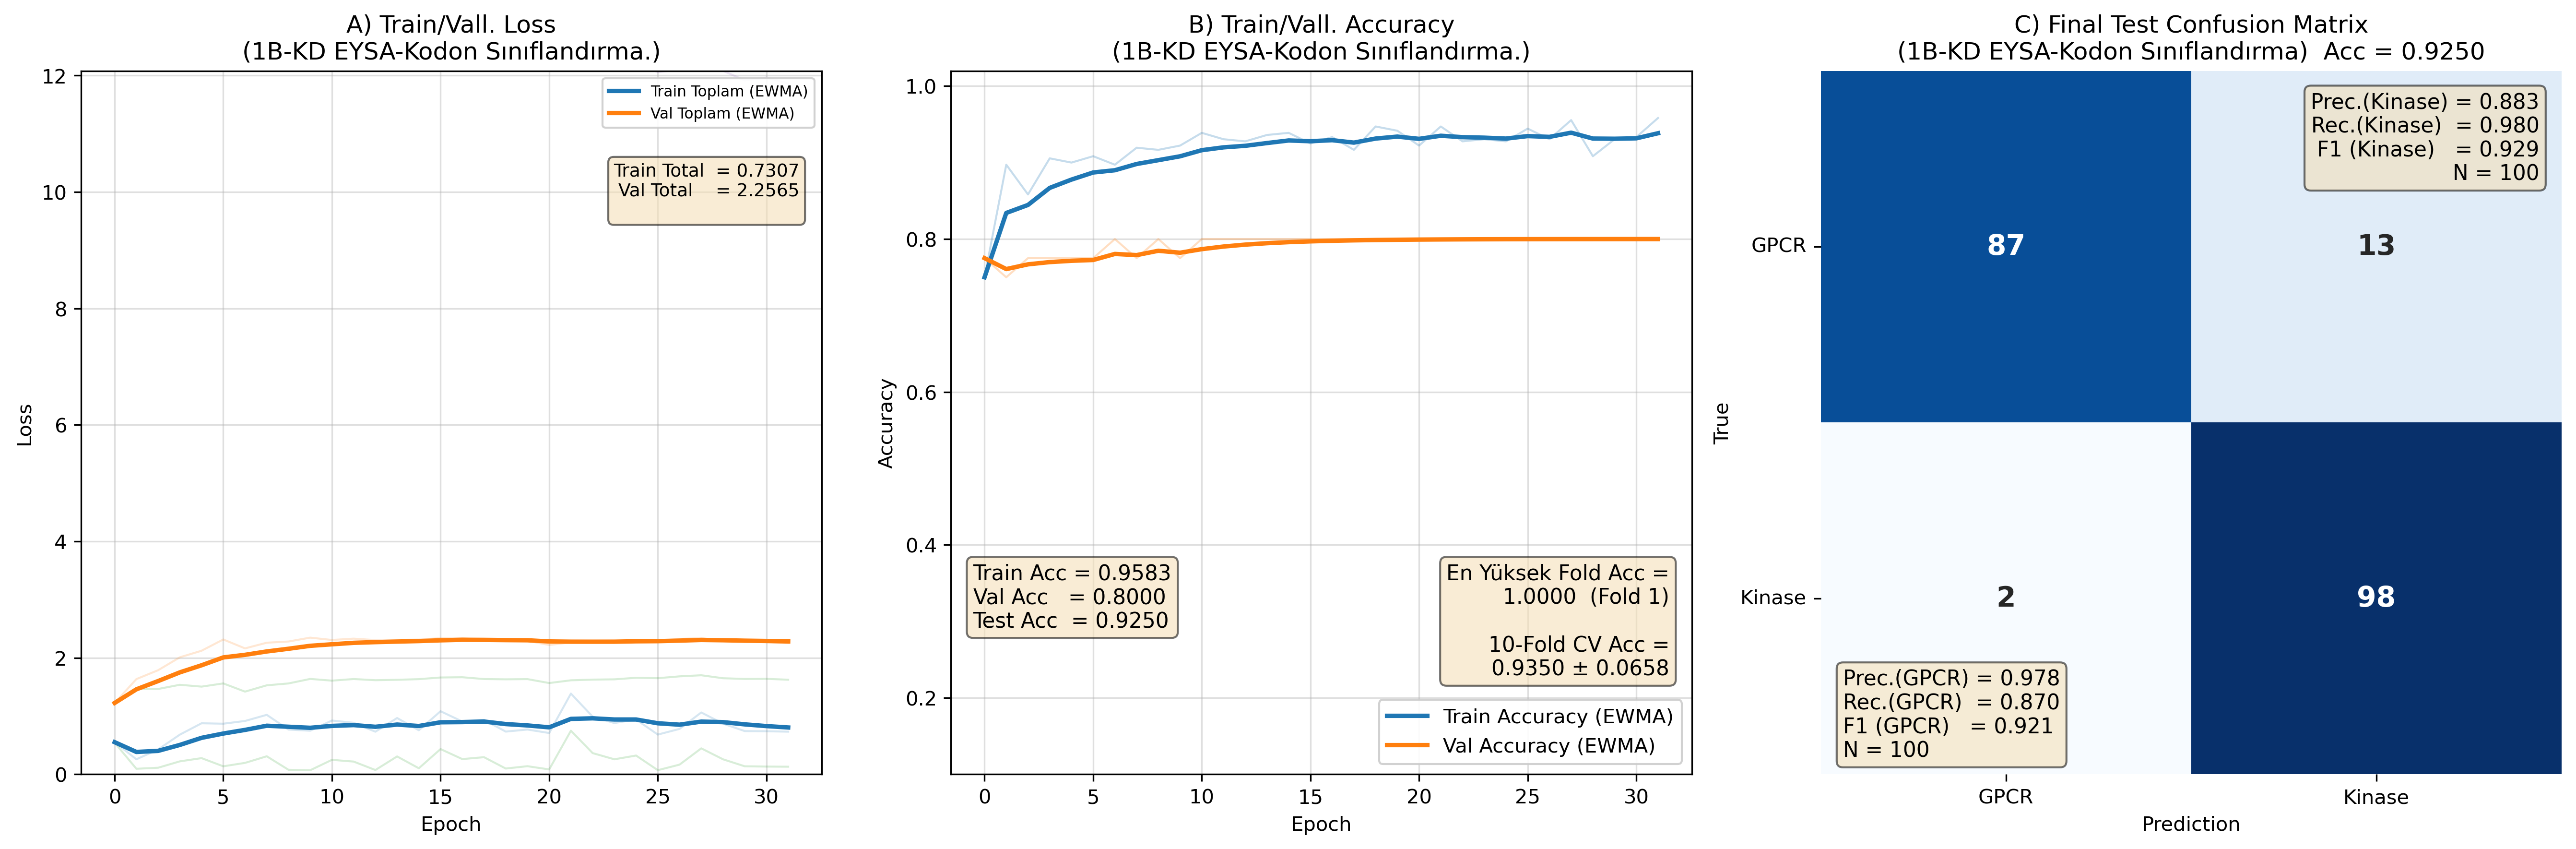

In [5]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B EVRİŞİMLİ KDYSA   [DNA / Kodon / AA ortak]
# 
#
#   Panel A : Toplam + CE + Center Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#

# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algıla
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "KDYSA"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilsE


# -------------------------------------------------------------------------
# 1.  History anahtarları — 1D Conv KDYSA ile birebir eşleşir
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham   = np.asarray(h[LOSS_KEY],       dtype=float)
val_loss_ham     = np.asarray(h[VAL_LOSS_KEY],   dtype=float)
train_acc_ham    = np.asarray(h[ACC_KEY],         dtype=float)
val_acc_ham      = np.asarray(h[VAL_ACC_KEY],     dtype=float)

# CE ve Center bileşen dizileri
train_ce_ham     = np.asarray(h.get(CE_KEY,     [np.nan]), dtype=float)
val_ce_ham       = np.asarray(h.get(VAL_CE_KEY, [np.nan]), dtype=float)
train_ctr_ham    = np.asarray(h.get(CENTER_KEY,     [np.nan]), dtype=float)
val_ctr_ham      = np.asarray(h.get(VAL_CENTER_KEY, [np.nan]), dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)
train_ce_sm   = ewma_yumusat(train_ce_ham,   alpha=0.25)
val_ce_sm     = ewma_yumusat(val_ce_ham,     alpha=0.25)
train_ctr_sm  = ewma_yumusat(train_ctr_ham,  alpha=0.25)
val_ctr_sm    = ewma_yumusat(val_ctr_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son   = float(train_loss_ham[-1])
val_loss_son     = float(val_loss_ham[-1])
train_acc_son    = float(train_acc_ham[-1])
val_acc_son      = float(val_acc_ham[-1])
train_ce_son     = float(train_ce_ham[-1])   if CE_KEY     in h else np.nan
val_ce_son       = float(val_ce_ham[-1])     if VAL_CE_KEY in h else np.nan
train_center_son = float(train_ctr_ham[-1])  if CENTER_KEY     in h else np.nan
val_center_son   = float(val_ctr_ham[-1])    if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet  — 1D Conv KDYSA sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_best_val_ce_mean   = cv_df["best_val_ce"].mean()      # 
cv_best_val_ce_std    = cv_df["best_val_ce"].std(ddof=1)
cv_best_val_ctr_mean  = cv_df["best_val_center"].mean()  
cv_best_val_ctr_std   = cv_df["best_val_center"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam + CE + Center son değerler + en düşük fold loss ──────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN  = "#1f77b4"   # mavi  — train
C_VAL    = "#ff7f0e"   # turuncu — val
C_CE     = "#2ca02c"   # yeşil — CE bileşeni
C_CENTER = "#9467bd"   # mor   — Center bileşeni


# ==========================================================================
#  A) Toplam + CE + Center Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham,  color=C_TRAIN,  linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,    color=C_VAL,    linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ce_ham,    color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ce_ham,      color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ctr_ham,   color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ctr_ham,     color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm,  color=C_TRAIN,  linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,    linewidth=2.2, label="Val Toplam (EWMA)")
#ax[0].plot(train_ce_sm,    color=C_CE,     linewidth=1.8, linestyle="--", label="Train CE^ℂ (EWMA)")
#ax[0].plot(val_ce_sm,      color=C_CE,     linewidth=1.8, linestyle=":",  label="Val CE^ℂ (EWMA)")
#ax[0].plot(train_ctr_sm,   color=C_CENTER, linewidth=1.8, linestyle="--", label="Train Cnt^ℂ (EWMA)")
#ax[0].plot(val_ctr_sm,     color=C_CENTER, linewidth=1.8, linestyle=":",  label="Val Cnt^ℂ (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Train/Vall. Loss\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.15))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Train/Vall. Accuracy\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B-KD EYSA-{TEMSIL} Sınıflandırma)  Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_1dconv_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 3.Adım: 1B KD EYSA  ile kompleks değerli AMİNO ASİT dizisi sınıflandırma:
- Daha önce önerilen matematiksel yöntemlerle kompleks değerlere kodlanmış AMİNO ASİT dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri 1B KD EYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [12]:
# =============================================================================
#   1B EVRİŞİMLİ KOMPLEKS DEĞERLİ YAPAY SİNİR AĞI (1B-KD EYSA) — Amino asit
#   L = 300 (300 kalıntı)   |   Veri kaynağı: AA_Compleks_L300.npz
#   (WİRTİNGER HİBRİT TOPLAM LOSS/KAYIP)
#
# =============================================================================

import os
import random
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#   SABİTLER
# =============================================================================
NPZ_YOLU = r"C:\Users\matya\AA_Compleks_L300.npz"

L                = 300   # AA: 300 kalıntı
SINIF_SAYISI     = 2
SINIF_ADLARI     = {0: "GPCR", 1: "Kinase"}

# Genlik (ham geldiği için sabit bölme Yapılarak normalzsyn. yapılmakta.)
GENLIK_NORMALIZASYONU = True

N_SPLITS         = 10
EPOCHS           = 200
BATCH_SIZE       = 12
OGRENME_ORANI    = 2e-4
WEIGHT_DECAY     = 1e-4

# hiperparametreler
LAMBDA_CENTER_HEDEF      = 0.05
LAMBDA_CENTER_BASLANGIC  = 0.0
LAMBDA_WARMUP_EPOCH      = 5
LABEL_SMOOTHING          = 0.02
TEMPERATURE              = 0.5

DROPOUT_ORANLARI         = (0.15, 0.20, 0.25)

CV_CIKTI_XLSX            = "cv_10_fold_1dconv_aa.xlsx"


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Ana run seed       : {RUN_SEED}")
print(f"[INFO] Veri kaynağı       : {NPZ_YOLU}")
print(f"[INFO] L (girdi uzunluğu) : {L}")
print(f"[INFO] Genlik norm. (X/L) : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef     : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Temperature τ      : {TEMPERATURE}")
print(f"[INFO] EarlyStop monitor  : val_dogruluk (max)")
print(f"[INFO] ReduceLR monitor   : val_kayip_ce")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# =============================================================================
#  KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#   KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma_r = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_r")
        self.beta_r  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_r")
        self.gamma_i = self.add_weight(shape=(d,), initializer="ones",  trainable=True, name="gamma_i")
        self.beta_i  = self.add_weight(shape=(d,), initializer="zeros", trainable=True, name="beta_i")

    def call(self, z):
        zr = tf.math.real(z)
        zi = tf.math.imag(z)
        axes = list(range(len(z.shape) - 1))

        ort_r  = tf.reduce_mean(zr, axis=axes, keepdims=True)
        var_r  = tf.math.reduce_variance(zr, axis=axes, keepdims=True)
        zr_hat = (zr - ort_r) / tf.sqrt(var_r + self.eps)
        zr_hat = zr_hat * self.gamma_r + self.beta_r

        ort_i  = tf.reduce_mean(zi, axis=axes, keepdims=True)
        var_i  = tf.math.reduce_variance(zi, axis=axes, keepdims=True)
        zi_hat = (zi - ort_i) / tf.sqrt(var_i + self.eps)
        zi_hat = zi_hat * self.gamma_i + self.beta_i

        return tf.complex(zr_hat, zi_hat)


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        mask = tf.nn.dropout(
            tf.ones_like(tf.math.real(z), dtype=tf.float32), rate=self.oran)
        return z * tf.cast(mask, z.dtype)


# =============================================================================
#    KOMPLEKS YOĞUN & CONV
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d         = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikConv1D(layers.Layer):
    def __init__(self, filtre_sayisi, kernel_boyutu, stride=1, padding="same",
                 aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.filtre_sayisi = int(filtre_sayisi)
        self.kernel_boyutu = int(kernel_boyutu)
        self.stride        = int(stride)
        self.padding       = padding.upper()
        self.aktivasyon    = aktivasyon
        self.l2            = float(l2)
        self.seed          = int(seed)

    def build(self, input_shape):
        ic        = int(input_shape[-1])
        base_init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        olcek     = 1.0 / np.sqrt(2.0)
        reg       = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None
        ks        = (self.kernel_boyutu, ic, self.filtre_sayisi)

        def si(shape, dtype=None):
            return tf.cast(base_init(shape, dtype=dtype), tf.float32) * olcek

        self.kr = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="kr")
        self.ki = self.add_weight(shape=ks, initializer=si, regularizer=reg,
                                  trainable=True, name="ki")
        self.br = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.filtre_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = (tf.nn.conv1d(xr, self.kr, stride=self.stride, padding=self.padding)
              - tf.nn.conv1d(xi, self.ki, stride=self.stride, padding=self.padding)
              + self.br)
        yi = (tf.nn.conv1d(xr, self.ki, stride=self.stride, padding=self.padding)
              + tf.nn.conv1d(xi, self.kr, stride=self.stride, padding=self.padding)
              + self.bi)
        y = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


class KarmasikMaxPool1D(layers.Layer):
    def __init__(self, pool_size=2, strides=2, padding="same", **kwargs):
        super().__init__(**kwargs)
        self.pool_size = int(pool_size)
        self.strides   = int(strides)
        self.padding   = padding.upper()

    def call(self, z):
        return tf.complex(
            tf.nn.max_pool1d(tf.math.real(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding),
            tf.nn.max_pool1d(tf.math.imag(z), ksize=self.pool_size,
                             strides=self.strides, padding=self.padding))


class KarmasikGlobalAveragePooling1D(layers.Layer):
    def call(self, z):
        return tf.complex(tf.reduce_mean(tf.math.real(z), axis=1),
                          tf.reduce_mean(tf.math.imag(z), axis=1))


# =============================================================================
#   WIRTINGER CE & CENTER KAYBI
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):

    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):

    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 temperature=0.5, stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.temperature         = float(temperature)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        logit = -enerji / self.temperature
        return logit, enerji


# =============================================================================
#     EĞİTİCİ MODEL
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#    CALLBACKS
# =============================================================================
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=5, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


def callback_listesi_olustur(reduce_lr_patience=10, early_stop_patience=25,
                             reduce_verbose=0, early_verbose=0,
                             scheduler_verbose=0):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_dogruluk", mode="max",
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_kayip_ce", factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=scheduler_verbose),
    ]


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               dropout_oranlari=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI,
               temperature=TEMPERATURE):

    d1, d2, d3 = dropout_oranlari

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")
    x     = layers.Reshape((L, 1), name="reshape_1d")(giris)

    # Blok 1
    x = KarmasikConv1D(16, 7, stride=1, padding="same", aktivasyon=None,
                       l2=wd, seed=seed,     name="kconv1")(x)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_1")(x)
    x = KarmasikDropout(oran=d1, name="drop_1")(x)

    # Blok 2
    x = KarmasikConv1D(32, 5, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 1, name="kconv2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikMaxPool1D(pool_size=2, strides=2, padding="same", name="pool_2")(x)
    x = KarmasikDropout(oran=d2, name="drop_2")(x)

    # Blok 3
    x = KarmasikConv1D(48, 3, stride=1, padding="same", aktivasyon=komplex_tanh,
                       l2=wd, seed=seed + 2, name="kconv3")(x)
    x = KarmasikKatmanNorm(name="norm_3")(x)
    x = KarmasikDropout(oran=d3, name="drop_3")(x)

    x = KarmasikGlobalAveragePooling1D(name="kgap")(x)

    z = KarmasikYogun(16, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 3, name="yogun_son")(x)
    z = KarmasikKatmanNorm(name="norm_son")(z)

    kodlayici = Model(giris, z, name="Karmasik1DConvKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      temperature=temperature,
                                      seed=seed + 4, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=LAMBDA_CENTER_BASLANGIC,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme 
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):

    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    assert X_tr.shape[1] == L, f"Eğitim dizi uzunluğu {X_tr.shape[1]} != L={L}"
    assert X_te.shape[1] == L, f"Test dizi uzunluğu {X_te.shape[1]} != L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,        y_test,        y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n=== VERİ BİLGİSİ ===")
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")
print("====================\n")


# =============================================================================
#     10-FOLD CV
# =============================================================================
skf            = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                                 random_state=SPLIT_SEED)
fold_sonuclari = []
histories      = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model     = modeli_kur(L=L, seed=fold_seed)
    callbacks = callback_listesi_olustur()

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)
    histories.append(history.history)

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec,
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss": best_val_loss,
        "best_val_acc":  best_val_acc,
        "best_val_ce":   best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":  len(h["kayip"]),
    })

    print(f"Fold Acc      : {fold_acc:.4f}  |  Macro F1  : {macro_f1:.4f}")
    print(f"GPCR F1       : {f1_cls[0]:.4f}  |  Kinase F1 : {f1_cls[1]:.4f}")
    print(f"Best Val Acc  : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı  : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit, 1D-Conv, AA)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce", "best_val_center",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_precision", "macro_recall", "macro_f1",
          "gpcr_precision", "gpcr_recall", "gpcr_f1",
          "kinase_precision", "kinase_recall", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:25s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    reduce_lr_patience=10, early_stop_patience=25,
    reduce_verbose=1, early_verbose=1, scheduler_verbose=1)

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE, shuffle=True,
    callbacks=final_callbacks, verbose=1)


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval   = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
macro_prec_t, macro_rec_t, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST SONUCU  (1D-Conv KDYSA, AA)")
print("=" * 55)
print("Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy        : {test_acc:.4f}")
print(f"Test Loss (toplam)   : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE    : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt   : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1        : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R        : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R        : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")

[INFO] Ana run seed       : 6669381
[INFO] Veri kaynağı       : C:\Users\matya\AA_Compleks_L300.npz
[INFO] L (girdi uzunluğu) : 300
[INFO] Genlik norm. (X/L) : True
[INFO] λ_center hedef     : 0.05 (warmup: 5 epoch)
[INFO] Temperature τ      : 0.5
[INFO] EarlyStop monitor  : val_dogruluk (max)
[INFO] ReduceLR monitor   : val_kayip_ce

=== VERİ BİLGİSİ ===
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 300)  |  X_test (200, 300)
|X| aralığı : [0.003333, 1]  (genlik_bol=True)


  FOLD 1/10
Fold Acc      : 0.9750  |  Macro F1  : 0.9750
GPCR F1       : 0.9744  |  Kinase F1 : 0.9756
Best Val Acc  : 0.9750  |  Best Val CE : 0.0748
Epoch sayısı  : 27

  FOLD 2/10
Fold Acc      : 0.9250  |  Macro F1  : 0.9250
GPCR F1       : 0.9231  |  Kinase F1 : 0.9268
Best Val Acc  : 0.9500  |  Best Val CE : 0.0569
Epoch sayısı  : 27

  FOLD 3/10
Fold Acc      : 0.9000  |  Macro F1  : 0.9000
GPCR F1       : 0.9000  |  Kinase F1 : 0.9000
Best Va

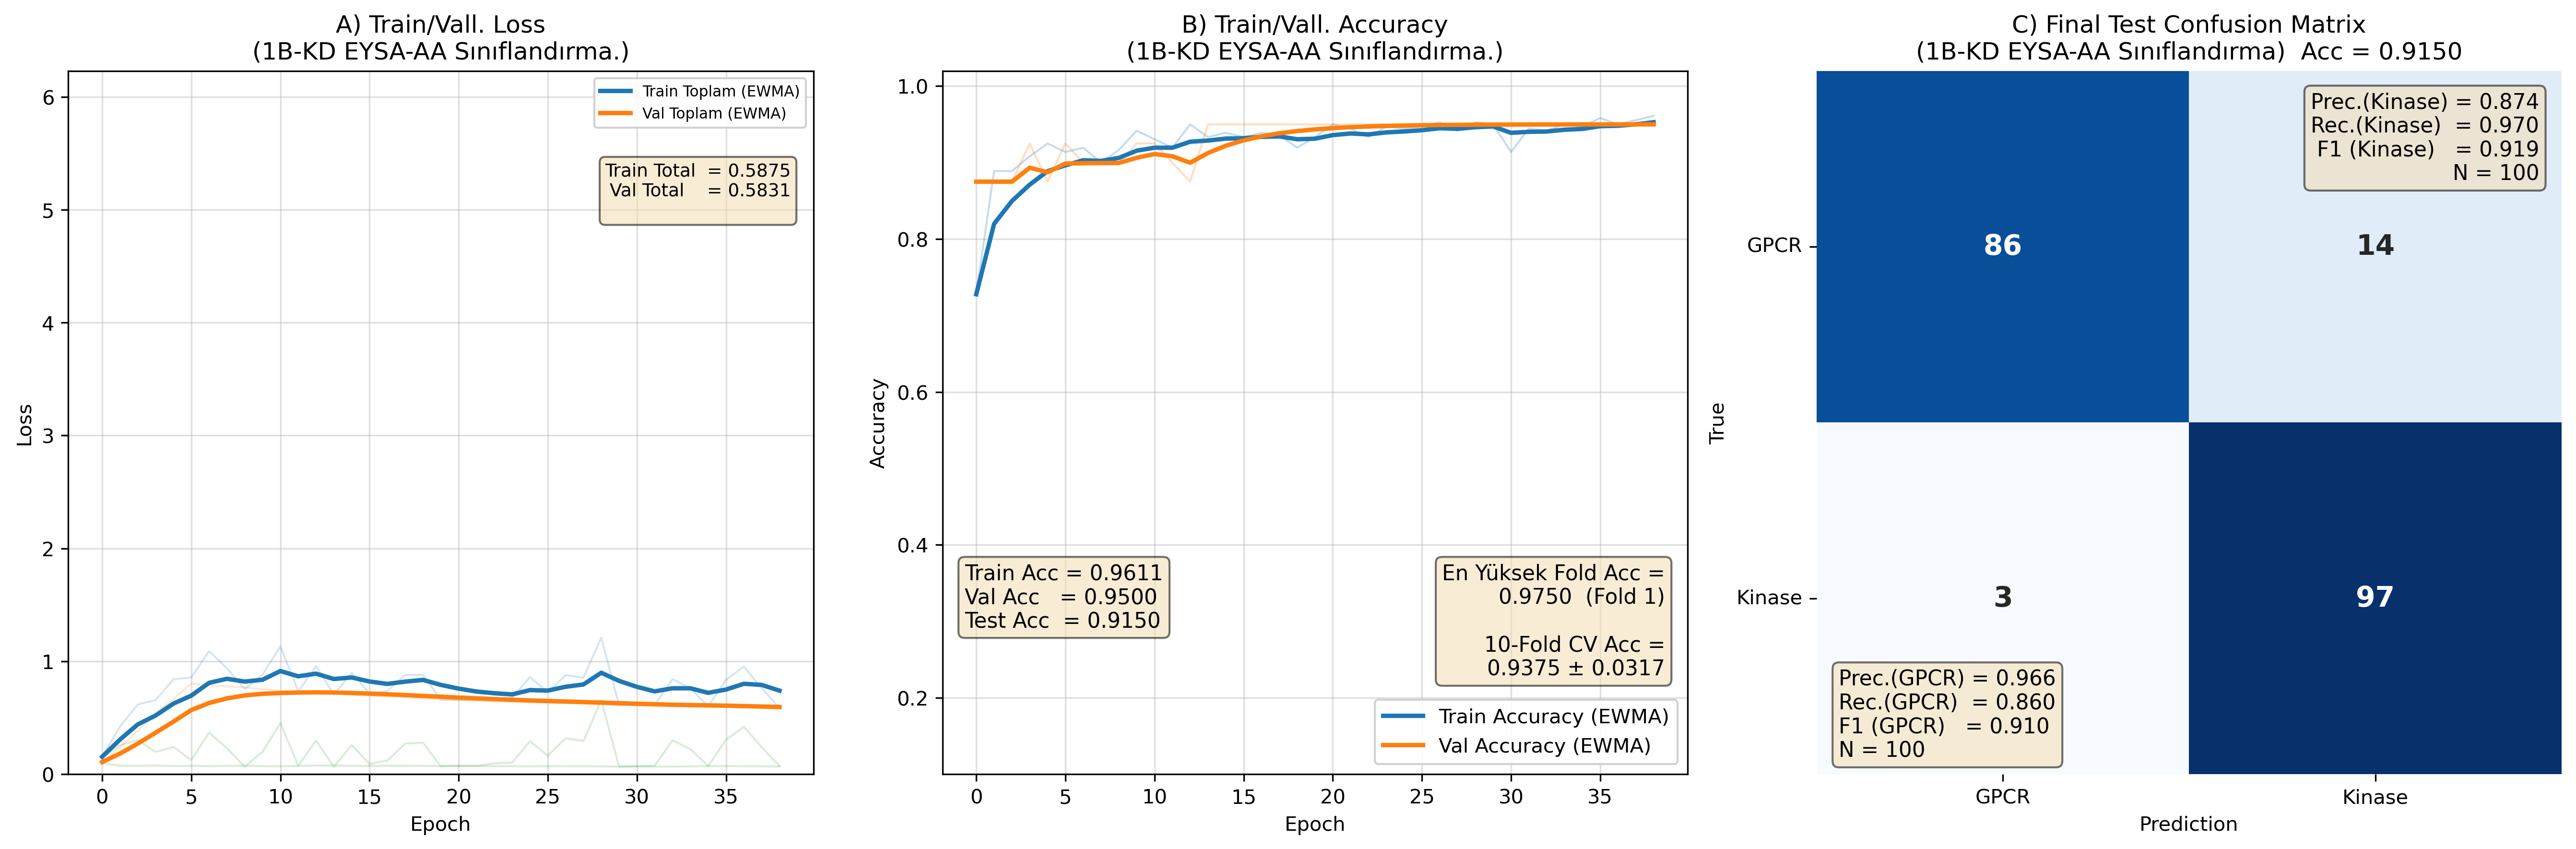

In [13]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B EVRİŞİMLİ KDYSA   [DNA / Kodon / AA ortak]
# 
#
#   Panel A : Toplam + CE + Center Loss (EWMA yumuşatmalı)
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix + sınıf bazlı metrik kutuları
#
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algılar
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "KDYSA"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse  "DNA" / "Kodon" / "AA"


# -------------------------------------------------------------------------
# 1.  History anahtarları — 1D Conv KDYSA ile birebir eşleşir
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham   = np.asarray(h[LOSS_KEY],       dtype=float)
val_loss_ham     = np.asarray(h[VAL_LOSS_KEY],   dtype=float)
train_acc_ham    = np.asarray(h[ACC_KEY],         dtype=float)
val_acc_ham      = np.asarray(h[VAL_ACC_KEY],     dtype=float)

# CE ve Center bileşen dizileri
train_ce_ham     = np.asarray(h.get(CE_KEY,     [np.nan]), dtype=float)
val_ce_ham       = np.asarray(h.get(VAL_CE_KEY, [np.nan]), dtype=float)
train_ctr_ham    = np.asarray(h.get(CENTER_KEY,     [np.nan]), dtype=float)
val_ctr_ham      = np.asarray(h.get(VAL_CENTER_KEY, [np.nan]), dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)
train_ce_sm   = ewma_yumusat(train_ce_ham,   alpha=0.25)
val_ce_sm     = ewma_yumusat(val_ce_ham,     alpha=0.25)
train_ctr_sm  = ewma_yumusat(train_ctr_ham,  alpha=0.25)
val_ctr_sm    = ewma_yumusat(val_ctr_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son   = float(train_loss_ham[-1])
val_loss_son     = float(val_loss_ham[-1])
train_acc_son    = float(train_acc_ham[-1])
val_acc_son      = float(val_acc_ham[-1])
train_ce_son     = float(train_ce_ham[-1])   if CE_KEY     in h else np.nan
val_ce_son       = float(val_ce_ham[-1])     if VAL_CE_KEY in h else np.nan
train_center_son = float(train_ctr_ham[-1])  if CENTER_KEY     in h else np.nan
val_center_son   = float(val_ctr_ham[-1])    if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet  — 1D Conv KDYSA sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_best_val_ce_mean   = cv_df["best_val_ce"].mean()      # 
cv_best_val_ce_std    = cv_df["best_val_ce"].std(ddof=1)
cv_best_val_ctr_mean  = cv_df["best_val_center"].mean()  
cv_best_val_ctr_std   = cv_df["best_val_center"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam + CE + Center son değerler + en düşük fold loss ──────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN  = "#1f77b4"   # mavi  — train
C_VAL    = "#ff7f0e"   # turuncu — val
C_CE     = "#2ca02c"   # yeşil — CE bileşeni
C_CENTER = "#9467bd"   # mor   — Center bileşeni


# ==========================================================================
#  A) Toplam + CE + Center Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham,  color=C_TRAIN,  linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,    color=C_VAL,    linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ce_ham,    color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ce_ham,      color=C_CE,     linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_ctr_ham,   color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_ctr_ham,     color=C_CENTER, linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm,  color=C_TRAIN,  linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,    linewidth=2.2, label="Val Toplam (EWMA)")
#ax[0].plot(train_ce_sm,    color=C_CE,     linewidth=1.8, linestyle="--", label="Train CE^ℂ (EWMA)")
#ax[0].plot(val_ce_sm,      color=C_CE,     linewidth=1.8, linestyle=":",  label="Val CE^ℂ (EWMA)")
#ax[0].plot(train_ctr_sm,   color=C_CENTER, linewidth=1.8, linestyle="--", label="Train Cnt^ℂ (EWMA)")
#ax[0].plot(val_ctr_sm,     color=C_CENTER, linewidth=1.8, linestyle=":",  label="Val Cnt^ℂ (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Train/Vall. Loss\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.15))

ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Train/Vall. Accuracy\n(1B-KD EYSA-{TEMSIL} Sınıflandırma.)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B-KD EYSA-{TEMSIL} Sınıflandırma)  Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_1dconv_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()